# Components tour

`OmegaGW` composes **three swappable parts**:

* **perturbations** — the curvature spectrum $\mathcal{P}_\zeta(k)$;
* **kernel** — the transfer function for the source era;
* **integrator** — the numerical quadrature over the internal momenta $(s,t)$.

This page walks through the options for each, plus the shared inference interface.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)   # SIGW integrals need float64
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Figures: vector (SVG), transparent, theme-neutral so they read on
# both the light and dark documentation themes. (Set once.)
%config InlineBackend.figure_formats = ["svg"]
plt.rcParams.update({
    "figure.figsize": (6.2, 3.6),
    "figure.facecolor": "none", "axes.facecolor": "none",
    "savefig.facecolor": "none", "savefig.transparent": True,
    "axes.edgecolor": "#8a8fa3", "axes.labelcolor": "#8a8fa3",
    "xtick.color": "#8a8fa3", "ytick.color": "#8a8fa3",
    "text.color": "#8a8fa3",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": plt.cycler(color=["#3a8cc4", "#e0455c", "#20305f"]),
})

import numpy as np
from sigway.spectrum import OmegaGW
from sigway.kernels import RadiationKernel, InstantEMDKernel
from sigway.perturbations import AnalyticPerturbations
from sigway.single_field import SingleFieldPerturbations
from sigway.binned_pzeta import Binned_P_zeta

## 1. Perturbations — the spectrum $\mathcal{P}_\zeta(k)$

A `ScalarPerturbations` object knows how to evaluate $\mathcal{P}_\zeta(k,\theta)$ and
carries its parameter names. There are three ways to get one.

### (a) Analytic — a closed form

`AnalyticPerturbations(func, names)` wraps any callable `func(k, *params)`. Use the
built-in shapes or your own. If a parameter sits **inside an integration limit** (e.g. a
sharp cutoff $k_{\max}$) flag it with `nonsmooth_params` so the Jacobian uses finite
differences for it:

```python
src = AnalyticPerturbations(
    pzeta_flat_cutoff, ("As", "kmax"), nonsmooth_params=("kmax",)
)
```

### (b) Single-field inflation — solve the Mukhanov–Sasaki equation

`SingleFieldPerturbations` integrates the background
**and** the mode equations for a potential $V(\phi)$ and returns $\mathcal{P}_\zeta$.
The potential below has a quasi-inflection point (ultra-slow-roll) tuned to stay
CMB-consistent while enhancing small-scale power.

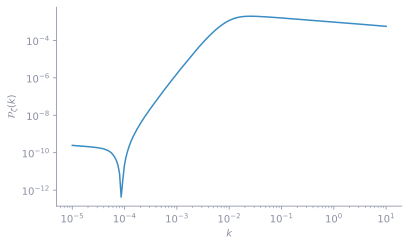

In [2]:
def usr_potential(phi, a, lam, v, nfac):
    b = (1 + nfac) * (1 - a**2/3 + a**2/3 * (9/(2*a**2) - 1)**(2/3))
    x = phi / v
    return lam * v**4/12 * x**2 * (6 - 4*a*x + 3*x**2) / (1 + b*x**2)**2

usr_pert = SingleFieldPerturbations(
    usr_potential, ("a", "lam", "v", "nfac"),
    phi0=3.0, N_CMB_to_end=58.0,
)
usr_params = (0.71224, 1.47312e-06, 0.19689, 1.86902e-05)

k = jnp.geomspace(1e-5, 10.0, 200)
plt.loglog(k, usr_pert(k, *usr_params))    # P_zeta from the solver
plt.xlabel("$k$")
plt.ylabel(r"$\mathcal{P}_\zeta(k)$");

### (c) Binned — model-independent

`Binned_P_zeta` represents $\mathcal{P}_\zeta$ as free log-amplitudes in $k$-bins, so you
can fit/forecast the spectrum without committing to a template. It is itself a full model
(precomputed coefficients, no $(s,t)$ integral) but exposes the **same** interface —
`parameter_names`, `__call__(f, *theta)`, `jacobian`.

('A_0', 'A_1', 'A_2') ... 100


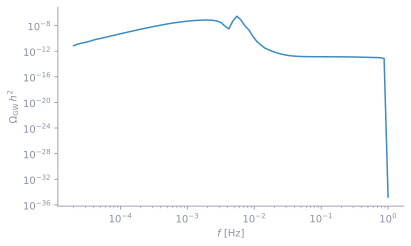

In [3]:
binned = Binned_P_zeta("binned", "Binned", nbins=100)
print(binned.parameter_names[:3], "...", len(binned.parameter_names))

amps = [-4.0]*len(binned.parameter_names)   # log10 bin amplitudes
amps[50] = 0.0                               # excite one bin
f_b = jnp.geomspace(2e-5, 1.0, 80)
plt.loglog(f_b, binned(f_b, *amps))
plt.xlabel("$f$ [Hz]")
plt.ylabel(r"$\Omega_{\mathrm{GW}}\,h^2$");

## 2. Kernels — the source era

The kernel is the time-integrated transfer function; swapping it changes the cosmology.

* **`RadiationKernel`** — radiation domination; $k$-independent (used in the
  [simple example](simple_example.ipynb)).
* **`InstantEMDKernel`** — an **early matter-dominated** era ending in a sudden transition
  to radiation; $k$-dependent and contributes one parameter, the transition time `etaR`.

Here the source is flat with a sharp cutoff at `kmax`:

('As', 'kmax', 'etaR')


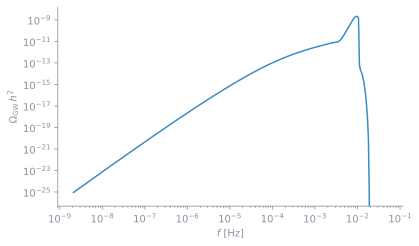

In [4]:
def pzeta_flat_cutoff(k, As, kmax):
    return jnp.heaviside(kmax - k, 1.0) * As

def t_emd(k, As, kmax, etaR):                # range must reach the cutoff
    return jnp.geomspace(1e-10*jnp.ones_like(k), 2*kmax/k, 100)

emd_source = AnalyticPerturbations(
    pzeta_flat_cutoff, ("As", "kmax"), nonsmooth_params=("kmax",)
)
emd_model = OmegaGW(
    emd_source, InstantEMDKernel(),
    s=jnp.linspace(0.0, 1.0, 100), t=t_emd,
)
print(emd_model.parameter_names)            # ('As', 'kmax', 'etaR')

f_emd = jnp.geomspace(2.1e-9, 5e-2, 350)
omega_emd = emd_model(f_emd, As=2.1e-9, kmax=0.06, etaR=2000.0)
plt.loglog(f_emd, omega_emd)
plt.xlabel("$f$ [Hz]")
plt.ylabel(r"$\Omega_{\mathrm{GW}}\,h^2$");

## 3. Integrators — the $(s,t)$ quadrature

The integrator owns the numerical method. The default is `SimpsonIntegrator(s, t)`:
fixed-grid Simpson quadrature over the two internal momenta. Passing `s=` and `t=` to
`OmegaGW` (as above) builds one for you.

Two practical points:

* **Grid spacing matters more than point count.** The integrand has a sharp feature near
  $t\lesssim1$ and a long tail above it; *linear below 1, geometric above* captures both.
  Pure log-spacing at the same count can leave the integral ~10 % high.
* **The grid can depend on $k$ and the parameters.** Pass a callable `t(k, *theta)` (as
  with `t_emd` above) so the range adapts to the source — e.g. always reaching a cutoff.

```python
def t_adaptive(k, logAs, logDelta, logks):
    ks = 10.0**logks
    upper = jnp.exp(4*10.0**logDelta) * (2*ks/k)
    lo = jnp.linspace(1e-5, 0.999, 200) * jnp.ones_like(k)
    hi = jnp.geomspace(jnp.ones_like(k), upper, 600)
    return jnp.concatenate([lo, hi], axis=0)
```

To use a different scheme entirely, subclass `Integrator` and pass it as `integrator=`.

## 4. The shared inference interface

Every model — analytic, single-field or binned — exposes one ordered parameter vector and
an autodiff Jacobian $\partial\Omega_{\mathrm{GW}}/\partial\theta$, the building block of a
Fisher forecast. Smooth parameters use forward-mode autodiff; `nonsmooth_params` fall back
to finite differences automatically.

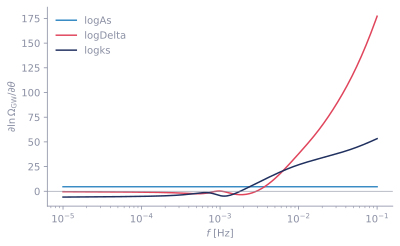

In [5]:
def pzeta_lognormal(k, logAs, logDelta, logks):
    As, Delta, ks = 10.0**logAs, 10.0**logDelta, 10.0**logks
    return As/(jnp.sqrt(2*jnp.pi)*Delta) * jnp.exp(-0.5/Delta**2*jnp.log(k/ks)**2)

model = OmegaGW(
    AnalyticPerturbations(pzeta_lognormal, ("logAs", "logDelta", "logks")),
    RadiationKernel(),
    s=jnp.linspace(0.0, 1.0, 10),
    t=jnp.concatenate([jnp.linspace(1e-5, 0.999, 200),
                       jnp.geomspace(1.0, 1e3, 800)]),
)

f = jnp.geomspace(1e-5, 1e-1, 200)
theta = [-2.5, -0.30103, -2.0]
jac = model.jacobian(f, theta)          # shape (len(f), n_params)
omega = model(f, *theta)

for i, name in enumerate(model.parameter_names):
    plt.semilogx(f, jac[:, i]/omega, label=name)   # d ln Omega / d theta
plt.axhline(0, lw=0.6, color="#8a8fa3")
plt.xlabel("$f$ [Hz]")
plt.ylabel(r"$\partial \ln \Omega_{\mathrm{GW}} / \partial\theta$")
plt.legend(frameon=False);